In [1]:
import torch
import deepinv as dinv
from deepinv.models.wrapper import DiffusersDenoiserWrapper

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
figsize = 2.5

from deepinv.sampling import PosteriorDiffusion, EulerSolver, VarianceExplodingDiffusion, VariancePreservingDiffusion
from deepinv.optim import ZeroFidelity


/users/aspagnol/venvs/dinv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# ----------------------------------------------------
#
# Let us first load a pretrained diffusion model from the HuggingFace Hub. Here, we use the `google/ddpm-ema-celebahq-256` model.
# This model is trained on 256x256 of CelebA dataset using the DDPM scheduler.

# We can wrap any diffusers model as a DeepInv denoiser using one line of code:
denoiser = DiffusersDenoiserWrapper(
    model_id="runwayml/stable-diffusion-v1-5", pipeline_name="StableDiffusionPipeline", device=device
)
from diffusers import DDIMScheduler
denoiser.scheduler = DDIMScheduler.from_config(denoiser.scheduler.config)

# Load an example image
x = dinv.utils.load_example(
    "celeba_example2.jpg",
    img_size=256,
    resize_mode="resize",
).to(device)

tokenizer = denoiser.tokenizer
text_encoder = denoiser.text_encoder

# Define the prompt
prompt = ["a photo of a cat"]

# Encode the prompt to conditioning embeddings
text_inputs = tokenizer(
    prompt, 
    padding="max_length", 
    max_length=tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt"
)

text_embeddings = text_encoder(text_inputs.input_ids.to(device))[0]

# # Add noise and test the denoiser
# sigma = 0.1
# x_noisy = x + sigma * torch.randn_like(x)
# with torch.no_grad():
#     x_denoised = denoiser(x_noisy, sigma=sigma)

# dinv.utils.plot(
#     [x, x_noisy, x_denoised],
#     figsize=(figsize * 3, figsize),
#     titles=["Original image", "Noisy image", "Denoised image"],
# )


/users/aspagnol/venvs/dinv/lib/python3.10/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  9.12it/s]


100%|██████████| 199/199 [00:06<00:00, 29.36it/s]


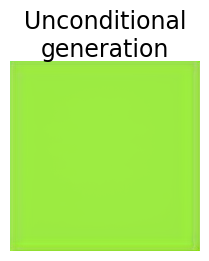

In [8]:
# ---------------------------------
#
# It is also possible to use the wrapped model for unconditional image generation.
# The model was trained with DDPM scheduler, however we can use it with any SDE provided in DeepInv.
# Here, we use the Variance Exploding SDE with Euler solver for sampling.

num_steps = 200
denoiser.scheduler.set_timesteps(num_steps, device=device)
rng = torch.Generator(device)
timesteps = torch.linspace(1, 0.001, num_steps)
solver = EulerSolver(timesteps=timesteps, rng=rng)

sde = VarianceExplodingDiffusion(
    device=device,
    dtype=dtype,
    alpha=0,
)

model = PosteriorDiffusion(
    data_fidelity=ZeroFidelity(),
    sde=sde,
    denoiser=denoiser,
    solver=solver,
    dtype=dtype,
    device=device,
    verbose=True,
    minus_one_one=False
)

z = torch.randn(1, 4, 64, 64, device=device, dtype=dtype)

sample, trajectory = model(
    y=None,
    physics=None,
    x_init=z,
    seed=42,
    get_trajectory=True,
    encoder_hidden_states=text_embeddings,
    denoise_output=False,
)
dinv.utils.plot(
    sample,
    titles="Unconditional generation",
    figsize=(figsize, figsize),
)


Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  4.89it/s]


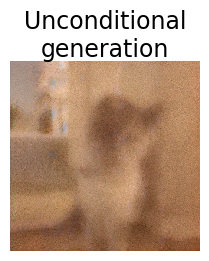

In [9]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler

model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda"
dtype = torch.float16

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
).to(device)

unet = pipe.unet
vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

prompt = "a photo of a cat"
num_steps = 200

# Text embedding
tokens = tokenizer(
    prompt,
    padding="max_length",
    max_length=tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt",
).input_ids.to(device)

with torch.no_grad():
    encoder_hidden_states = text_encoder(tokens)[0]

# Initial latent noise: [B, 4, H/8, W/8]
z = torch.randn(1, 4, 64, 64, device=device, dtype=dtype)

scheduler.set_timesteps(num_steps, device=device)

# DDIM sampling
with torch.no_grad():
    for t in scheduler.timesteps:

        #z_in = scheduler.scale_model_input(z, t)

        eps = unet(
            z,
            t,
            encoder_hidden_states=encoder_hidden_states,
        ).sample

        z = scheduler.step(
            eps,
            t,
            z,
            eta=0.0,
        ).prev_sample

# SD latent -> raw VAE latent
z = z / vae.config.scaling_factor

# Decode
with torch.no_grad():
    x = vae.decode(z).sample

# [-1,1] -> [0,1]
x = (x / 2 + 0.5).clamp(0, 1)
dinv.utils.plot(
    x,
    titles="Unconditional generation",
    figsize=(figsize, figsize),
)

In [ ]:
z = model.sde.denoiser.vae.encode((2*x - 1).clamp(-1,1)).latent_dist.sample()
x_dec = 0.5*model.sde.denoiser.vae.decode(z).sample + 0.5

dinv.utils.plot(
    [x, x_dec.clamp(0,1)],
    figsize=(figsize * 2, figsize),
    titles=["Original image", "Decoded image"],
)

In [ ]:
# ---------------------
#
# Similar to other denoisers in DeepInv, the wrapped diffusers model can be used for posterior sampling.
# Below we use the same VE-SDE for posterior sampling in an inpainting problem.

# Initialize the physics

mask = torch.ones_like(x)
mask[..., 70:150, 120:180] = 0
physics = dinv.physics.Inpainting(
    mask=mask,
    img_size=x.shape[1:],
    device=device,
    noise_model=dinv.physics.GaussianNoise(0.05),
)

y = physics(x)


In [ ]:

from deepinv.sampling import DPSDataFidelity

model = PosteriorDiffusion(
    data_fidelity=DPSDataFidelity(denoiser=denoiser, weight=1.0),
    denoiser=denoiser,
    sde=sde,
    solver=solver,
    dtype=dtype,
    device=device,
    verbose=True,
)


In [ ]:
posterior_sample = model(
    y=y,
    physics=physics,
    x_init=(1, 3, 256, 256),
    seed=15,
)
dinv.utils.plot(
    [x, y, posterior_sample],
    titles=["Original image", "Measurement", "Posterior sample"],
    figsize=(figsize * 3, figsize),
)
